<a href="https://colab.research.google.com/github/MSoledadGarcia/dm2025b/blob/main/src/Prueba%2320/Copia_de_boruta_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


In [ ]:
%%shell

mkdir -p "/content/.drive/My Drive/dm"
mkdir -p "/content/buckets"
ln -s "/content/.drive/My Drive/dm" /content/buckets/b1

mkdir -p ~/.kaggle
cp /content/buckets/b1/kaggle/kaggle.json  ~/.kaggle
chmod 600 ~/.kaggle/kaggle.json


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets



archivo_origen="https://storage.googleapis.com/open-courses/itba2025-8d0a/dataset_pequeno.csv"
archivo_destino="/content/datasets/dataset_pequeno.csv"
archivo_destino_bucket="/content/buckets/b1/datasets/dataset_pequeno.csv"

if ! test -f $archivo_destino_bucket; then
  wget  $archivo_origen  -O $archivo_destino_bucket
fi


if ! test -f $archivo_destino; then
  cp  $archivo_destino_bucket  $archivo_destino
fi


Entorno de ejecucion R


In [1]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 08 02:06:25 2025"

In [2]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,656948,35.1,1439374,76.9,1432166,76.5
Vcells,1225036,9.4,8388608,64.0,1924961,14.7


In [3]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
if(!require("rpart.plot")) install.packages("rpart.plot")
require("rpart.plot")

   #cargo Boruta
if(!require("Boruta")) install.packages("Boruta")
require("Boruta")


Loading required package: data.table

Loading required package: rpart

Loading required package: rpart.plot

Loading required package: Boruta



In [4]:
PARAM <- list()
PARAM$experimento <- 001
PARAM$semilla_primigenia <- 100019

In [5]:

# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("Boruta", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

In [6]:
# lectura del dataset
dataset <- fread("/content/datasets/dataset_pequeno.csv")

In [7]:
# defino los dataset de entrenamiento y aplicacion
dtrain <- dataset[foto_mes == 202107]
dfuture <- dataset[foto_mes == 202109]

In [ ]:
#summary(dtrain)

Convierto clase ternaria a factor, ya que random forest necesita ese formato

In [8]:
dtrain$clase_ternaria <- as.factor(dtrain$clase_ternaria)


In [10]:


# Nombre del archivo donde guardaremos el progreso
archivo_boruta <- "boruta_resultado.rds"

# Chequear si ya existe un resultado previo
if (file.exists(archivo_boruta)) {
  # Si existe, lo cargo
  message(" Cargando Boruta desde archivo guardado...")
  boruta.train <- readRDS(archivo_boruta)
} else {
  # Si no existe, corro Boruta desde cero
  message("Ejecutando Boruta desde cero...")
  set.seed(123)
  boruta.train <- Boruta(clase_ternaria ~ .,
                         data = dtrain,
                         doTrace = 2,
                         ntree = 200,   #defaul=500, cambio para q sea mas rapido
                         maxRuns = 20) #defaul=100, cambio para q sea mas rapido

  # Guardar el resultado para continuar más adelante si se corta
  saveRDS(boruta.train, archivo_boruta)
}


Ejecutando Boruta desde cero...

 1. run of importance source...



Growing trees.. Progress: 14%. Estimated remaining time: 3 minutes, 18 seconds.
Growing trees.. Progress: 28%. Estimated remaining time: 2 minutes, 43 seconds.
Growing trees.. Progress: 42%. Estimated remaining time: 2 minutes, 9 seconds.
Growing trees.. Progress: 56%. Estimated remaining time: 1 minute, 38 seconds.
Growing trees.. Progress: 70%. Estimated remaining time: 1 minute, 7 seconds.
Growing trees.. Progress: 84%. Estimated remaining time: 36 seconds.
Growing trees.. Progress: 99%. Estimated remaining time: 3 seconds.
Computing permutation importance.. Progress: 3%. Estimated remaining time: 22 minutes, 45 seconds.
Computing permutation importance.. Progress: 6%. Estimated remaining time: 20 minutes, 54 seconds.
Computing permutation importance.. Progress: 9%. Estimated remaining time: 19 minutes, 22 seconds.
Computing permutation importance.. Progress: 12%. Estimated remaining time: 18 minutes, 35 seconds.
Computing permutation importance.. Progress: 14%. Estimated remaining 

 2. run of importance source...



Growing trees.. Progress: 14%. Estimated remaining time: 3 minutes, 10 seconds.
Growing trees.. Progress: 28%. Estimated remaining time: 2 minutes, 46 seconds.
Growing trees.. Progress: 42%. Estimated remaining time: 2 minutes, 13 seconds.
Growing trees.. Progress: 56%. Estimated remaining time: 1 minute, 41 seconds.
Growing trees.. Progress: 70%. Estimated remaining time: 1 minute, 9 seconds.
Growing trees.. Progress: 83%. Estimated remaining time: 38 seconds.
Growing trees.. Progress: 97%. Estimated remaining time: 8 seconds.
Computing permutation importance.. Progress: 3%. Estimated remaining time: 23 minutes, 24 seconds.
Computing permutation importance.. Progress: 6%. Estimated remaining time: 21 minutes, 11 seconds.
Computing permutation importance.. Progress: 9%. Estimated remaining time: 20 minutes, 5 seconds.
Computing permutation importance.. Progress: 12%. Estimated remaining time: 18 minutes, 58 seconds.
Computing permutation importance.. Progress: 14%. Estimated remaining 

 3. run of importance source...



...

 18. run of importance source...



Growing trees.. Progress: 22%. Estimated remaining time: 1 minute, 53 seconds.
Growing trees.. Progress: 44%. Estimated remaining time: 1 minute, 20 seconds.
Growing trees.. Progress: 66%. Estimated remaining time: 49 seconds.
Growing trees.. Progress: 87%. Estimated remaining time: 18 seconds.
Computing permutation importance.. Progress: 10%. Estimated remaining time: 5 minutes, 14 seconds.
Computing permutation importance.. Progress: 20%. Estimated remaining time: 4 minutes, 32 seconds.
Computing permutation importance.. Progress: 30%. Estimated remaining time: 3 minutes, 56 seconds.
Computing permutation importance.. Progress: 40%. Estimated remaining time: 3 minutes, 23 seconds.
Computing permutation importance.. Progress: 50%. Estimated remaining time: 2 minutes, 48 seconds.
Computing permutation importance.. Progress: 59%. Estimated remaining time: 2 minutes, 16 seconds.
Computing permutation importance.. Progress: 69%. Estimated remaining time: 1 minute, 45 seconds.
Computing pe

 19. run of importance source...



Growing trees.. Progress: 22%. Estimated remaining time: 1 minute, 53 seconds.
Growing trees.. Progress: 44%. Estimated remaining time: 1 minute, 20 seconds.
Growing trees.. Progress: 65%. Estimated remaining time: 51 seconds.
Growing trees.. Progress: 87%. Estimated remaining time: 19 seconds.
Computing permutation importance.. Progress: 10%. Estimated remaining time: 5 minutes, 14 seconds.
Computing permutation importance.. Progress: 20%. Estimated remaining time: 4 minutes, 36 seconds.
Computing permutation importance.. Progress: 30%. Estimated remaining time: 4 minutes, 1 seconds.
Computing permutation importance.. Progress: 40%. Estimated remaining time: 3 minutes, 25 seconds.
Computing permutation importance.. Progress: 50%. Estimated remaining time: 2 minutes, 51 seconds.
Computing permutation importance.. Progress: 60%. Estimated remaining time: 2 minutes, 16 seconds.
Computing permutation importance.. Progress: 70%. Estimated remaining time: 1 minute, 42 seconds.
Computing per

After 19 iterations, +6.5 hours: 

 rejected 2 attributes: cmobile_app_trx, ctarjeta_debito;

 still have 40 attributes left.




In [11]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 08 08:36:58 2025"

In [12]:
# Estado final de cada variable
boruta.train$finalDecision

# Resumen rápido
table(boruta.train$finalDecision)

# Variables confirmadas como importantes
getSelectedAttributes(boruta.train, withTentative = FALSE)

# Variables importantes + tentativas (por si querés reanalizar)
getSelectedAttributes(boruta.train, withTentative = TRUE)

# Información detallada
attStats(boruta.train)  # dataframe con medias, medianas y decisiones


numero_de_cliente                             foto_mes 
                           Tentative                             Rejected 
                      active_quarter                          cliente_vip 
                            Rejected                             Rejected 
                            internet                         cliente_edad 
                            Rejected                            Tentative 
                  cliente_antiguedad                        mrentabilidad 
                           Tentative                            Tentative 
                mrentabilidad_annual                          mcomisiones 
                           Confirmed                             Rejected 
                     mactivos_margen                      mpasivos_margen 
                           Tentative                             Rejected 
                          cproductos                             tcuentas 
                           Tentative                             Rejected 
                   ccuenta_corriente          mcuenta_corriente_adicional 
                            Rejected                             Rejected 
                   mcuenta_corriente                         ccaja_ahorro 
                           Tentative                             Rejected 
                        mcaja_ahorro               mcaja_ahorro_adicional 
                            Rejected                             Rejected 
                mcaja_ahorro_dolares             cdescubierto_preacordado 
                           Tentative                            Tentative 
                      mcuentas_saldo                      ctarjeta_debito 
                           Tentative                             Rejected 
       ctarjeta_debito_transacciones                        mautoservicio 
                            Rejected                            Tentative 
                       ctarjeta_visa          ctarjeta_visa_transacciones 
                            Rejected                             Rejected 
               mtarjeta_visa_consumo                      ctarjeta_master 
                            Rejected                             Rejected 
       ctarjeta_master_transacciones              mtarjeta_master_consumo 
                            Rejected                             Rejected 
               cprestamos_personales                mprestamos_personales 
                           Tentative                            Tentative 
               cprestamos_prendarios                mprestamos_prendarios 
                            Rejected                             Rejected 
             cprestamos_hipotecarios              mprestamos_hipotecarios 
                            Rejected                             Rejected 
                         cplazo_fijo                  mplazo_fijo_dolares 
                            Rejected                             Rejected 
                   mplazo_fijo_pesos                          cinversion1 
                            Rejected                             Rejected 
                   minversion1_pesos                  minversion1_dolares 
                            Rejected                             Rejected 
                         cinversion2                          minversion2 
                            Rejected                             Rejected 
                        cseguro_vida                         cseguro_auto 
                            Rejected                             Rejected 
                    cseguro_vivienda        cseguro_accidentes_personales 
                            Rejected                             Rejected 
                     ccaja_seguridad                         cpayroll_trx 
                            Rejected                             Rejected 
                            mpayroll                            mpayroll2 
                            Rejected        


Tentative Confirmed  Rejected 
       40         1       113 

[1] "mrentabilidad_annual"

[1] "numero_de_cliente"                  "cliente_edad"                      
 [3] "cliente_antiguedad"                 "mrentabilidad"                     
 [5] "mrentabilidad_annual"               "mactivos_margen"                   
 [7] "cproductos"                         "mcuenta_corriente"                 
 [9] "mcaja_ahorro_dolares"               "cdescubierto_preacordado"          
[11] "mcuentas_saldo"                     "mautoservicio"                     
[13] "cprestamos_personales"              "mprestamos_personales"             
[15] "ccuenta_debitos_automaticos"        "mttarjeta_visa_debitos_automaticos"
[17] "mpagomiscuentas"                    "ccomisiones_mantenimiento"         
[19] "mcomisiones_mantenimiento"          "ccomisiones_otras"                 
[21] "ctransferencias_recibidas"          "tcallcenter"                       
[23] "ccallcenter_transacciones"          "chomebanking_transacciones"        
[25] "ccajas_otras"                       "tmobile_app"                       
[27] "Master_mfinanciacion_limite"        "Master_Fvencimiento"               
[29] "Master_msaldototal"                 "Master_msaldopesos"                
[31] "Master_mlimitecompra"               "Master_fechaalta"                  
[33] "Visa_mfinanciacion_limite"          "Visa_Fvencimiento"                 
[35] "Visa_msaldototal"                   "Visa_msaldopesos"                  
[37] "Visa_mlimitecompra"                 "Visa_mpagospesos"                  
[39] "Visa_fechaalta"                     "Visa_cconsumos"                    
[41] "Visa_mpagominimo"

,meanImp,medianImp,minImp,maxImp,normHits,decision
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
numero_de_cliente,42.3463214,43.499291,25.664068,52.578404,0.47368421,Tentative
foto_mes,0.0000000,0.000000,0.000000,0.000000,0.00000000,Rejected
active_quarter,37.9127643,37.849126,33.988967,42.191696,0.00000000,Rejected
cliente_vip,4.9829833,4.905092,4.063727,6.166792,0.00000000,Rejected
internet,43.9294860,43.768315,38.384885,48.682734,0.00000000,Rejected
cliente_edad,43.6818944,44.786536,34.846457,51.015078,0.78947368,Tentative
cliente_antiguedad,43.3106248,45.416482,28.535121,53.328991,0.68421053,Tentative
mrentabilidad,45.1492303,46.159095,37.775539,50.298017,0.84210526,Tentative
mrentabilidad_annual,46.6318908,46.852440,41.249880,53.576198,1.00000000,Confirmed


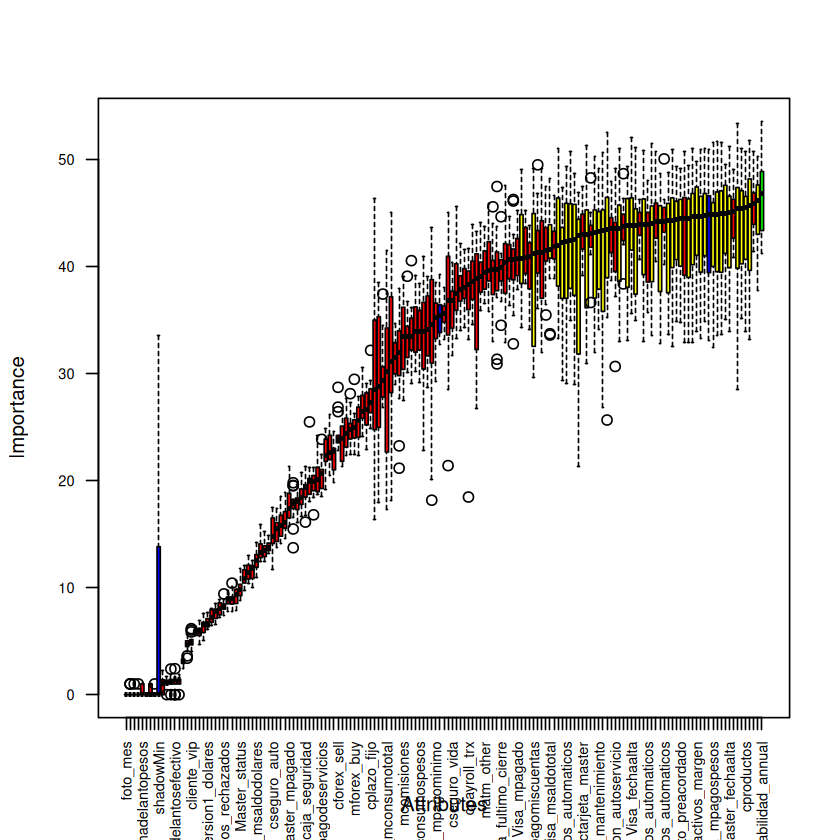

In [13]:
plot(boruta.train, las = 2, cex.axis = 0.7)


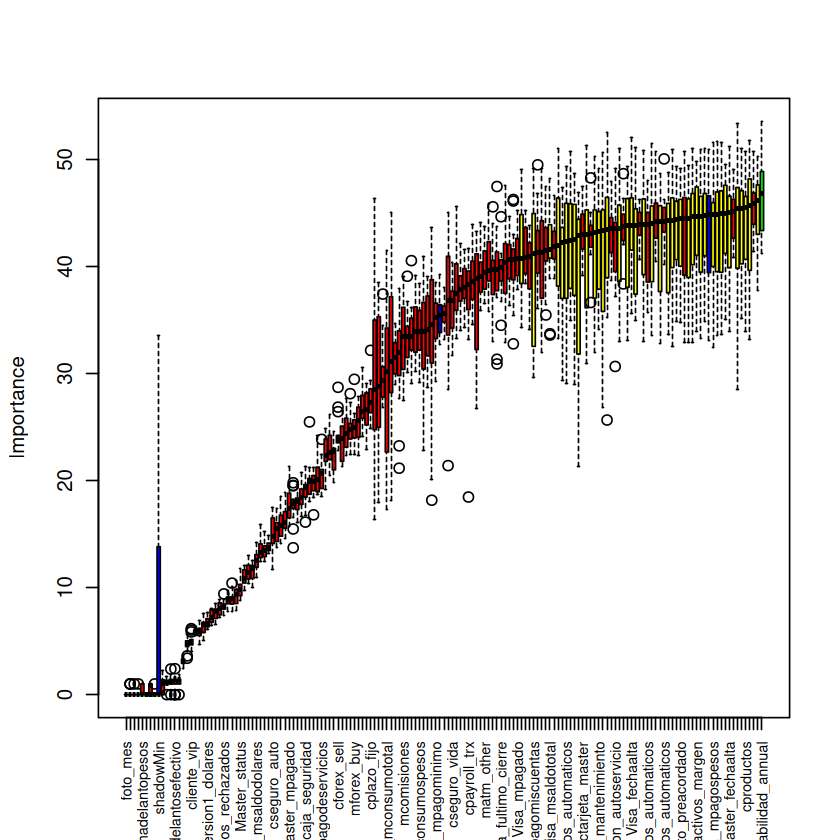

In [14]:
#ver q hace
plot(boruta.train, xlab = "", xaxt = "n")
lz<-lapply(1:ncol(boruta.train$ImpHistory),function(i)
boruta.train$ImpHistory[is.finite(boruta.train$ImpHistory[,i]),i])
names(lz) <- colnames(boruta.train$ImpHistory)
Labels <- sort(sapply(lz,median))
axis(side = 1,las=2,labels = names(Labels),
at = 1:ncol(boruta.train$ImpHistory), cex.axis = 0.7)